## Household electricity analysis

#### Importing libraries

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

#### Importing dataset
##### Here im analyzing 3BK base file

In [2]:
df = pd.read_csv(r'data\appliances_3BHK.csv')
df

,name,type,category,power_w,min_power_w,max_power_w,default_hours,continuous,count,total_power_w
0,Air Conditioner,1.5 Ton AC,Heating & Cooling,1500,1200,1800,6.0,False,3,4500
1,Water Heater,Geyser,Heating & Cooling,2500,2000,3000,0.5,False,2,5000
2,Space Heater,Room Heater,Heating & Cooling,1750,1500,2000,2.0,False,1,1750
3,Electric Iron,Steam Iron,Heating & Cooling,1750,1000,2500,0.5,False,1,1750
4,Induction Cooktop,Induction,Kitchen,1600,1200,2000,1.0,False,1,1600
5,Microwave Oven,Microwave,Kitchen,1250,1000,1500,0.3,False,1,1250
6,Electric Kettle,Kettle,Kitchen,1500,1200,1800,0.2,False,1,1500
7,Mixer Grinder,Mixer/Grinder,Kitchen,625,500,750,0.2,False,1,625
8,Refrigerator,Double Door,Kitchen,200,150,250,24.0,True,1,200
9,Washing Machine,Semi/Top Load,Utility & Laundry,750,500,1000,0.5,False,0,0


#### About dataset

In [3]:
df.head()

,name,type,category,power_w,min_power_w,max_power_w,default_hours,continuous,count,total_power_w
0,Air Conditioner,1.5 Ton AC,Heating & Cooling,1500,1200,1800,6.0,False,3,4500
1,Water Heater,Geyser,Heating & Cooling,2500,2000,3000,0.5,False,2,5000
2,Space Heater,Room Heater,Heating & Cooling,1750,1500,2000,2.0,False,1,1750
3,Electric Iron,Steam Iron,Heating & Cooling,1750,1000,2500,0.5,False,1,1750
4,Induction Cooktop,Induction,Kitchen,1600,1200,2000,1.0,False,1,1600


In [4]:
df.tail()

,name,type,category,power_w,min_power_w,max_power_w,default_hours,continuous,count,total_power_w
21,Smartphone Charger,Phone Charger,Electronics,8,5,12,2.0,False,4,32
22,LED Bulb,LED,Lighting,9,7,12,6.0,False,12,108
23,Tube Light,LED Tube,Lighting,20,18,22,6.0,False,5,100
24,CFL Bulb,CFL,Lighting,20,15,25,6.0,False,0,0
25,Incandescent Bulb,Traditional,Lighting,80,60,100,6.0,False,0,0


In [5]:
df.size

260

In [6]:
df.ndim

2

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           26 non-null     object 
 1   type           26 non-null     object 
 2   category       26 non-null     object 
 3   power_w        26 non-null     int64  
 4   min_power_w    26 non-null     int64  
 5   max_power_w    26 non-null     int64  
 6   default_hours  26 non-null     float64
 7   continuous     26 non-null     bool   
 8   count          26 non-null     int64  
 9   total_power_w  26 non-null     int64  
dtypes: bool(1), float64(1), int64(5), object(3)
memory usage: 2.0+ KB


In [8]:
df.describe()

,power_w,min_power_w,max_power_w,default_hours,count,total_power_w
count,26.000000,26.000000,26.000000,26.000000,26.000000,26.000000
mean,765.230769,584.153846,946.576923,5.065385,1.884615,962.576923
std,845.988336,666.657435,1034.476531,6.206638,2.581890,1348.014753
min,8.000000,5.000000,12.000000,0.200000,0.000000,0.000000
25%,61.250000,33.750000,72.500000,0.625000,1.000000,17.000000
50%,275.000000,175.000000,375.000000,5.000000,1.000000,275.000000
75%,1500.000000,1150.000000,1800.000000,6.000000,2.000000,1575.000000
max,2500.000000,2000.000000,3000.000000,24.000000,12.000000,5000.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isna().sum()

name             0
type             0
category         0
power_w          0
min_power_w      0
max_power_w      0
default_hours    0
continuous       0
count            0
total_power_w    0
dtype: int64

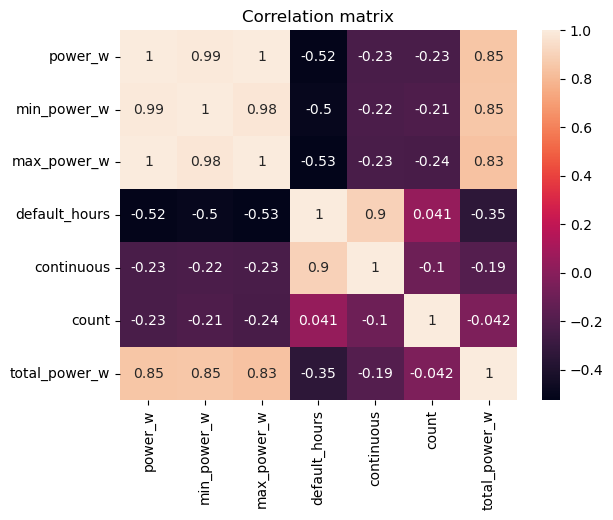

In [14]:
corr = df.corr(numeric_only=True)
plt.title("Correlation matrix")
sns.heatmap(corr,annot=True)
plt.show()

#### Visualizations

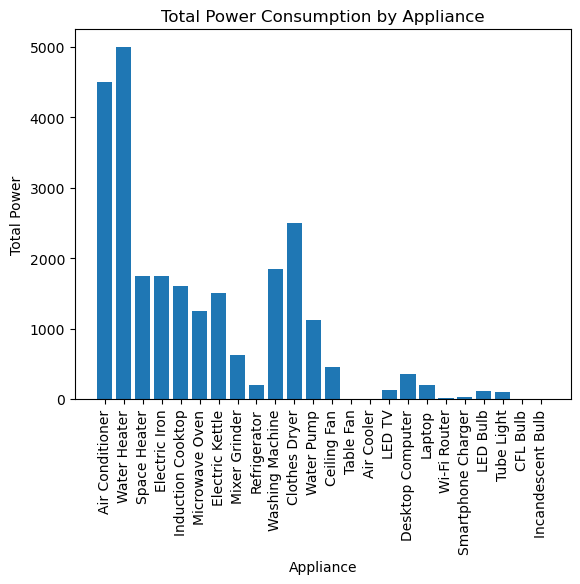

In [21]:

plt.bar(df["name"], df["total_power_w"])

plt.title("Total Power Consumption by Appliance")
plt.xlabel("Appliance")
plt.ylabel("Total Power")
plt.xticks(rotation=90)
plt.show()

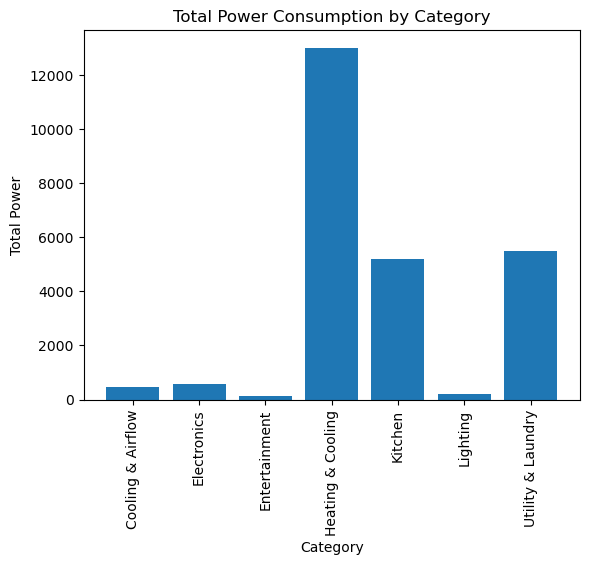

In [26]:
category_power = df.groupby("category")["total_power_w"].sum()
plt.bar(category_power.index, category_power.values)
plt.title("Total Power Consumption by Category")
plt.xlabel("Category")
plt.ylabel("Total Power")
plt.xticks(rotation=90)
plt.show()

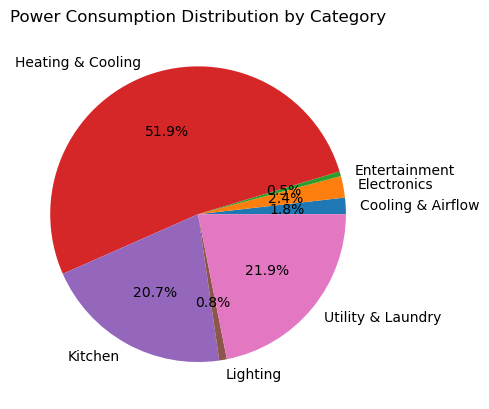

In [27]:
plt.pie(
    category_power.values,
    labels=category_power.index,
    autopct="%1.1f%%"
)

plt.title("Power Consumption Distribution by Category")

plt.show()

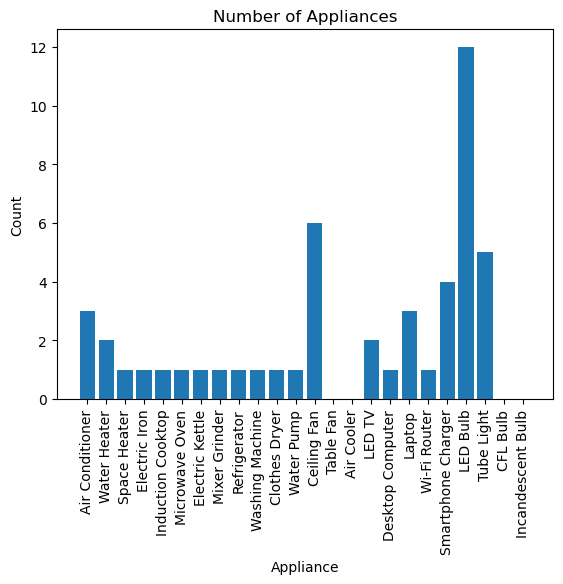

In [29]:
plt.bar(df["name"], df["count"])
plt.title("Number of Appliances")
plt.xlabel("Appliance")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

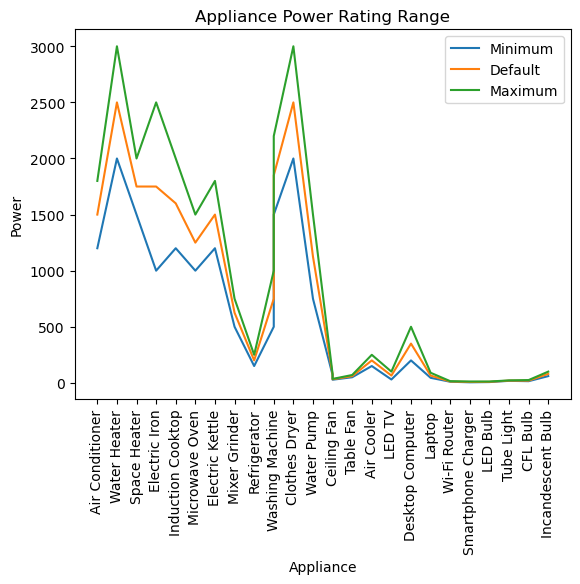

In [36]:
plt.plot(df["name"], df["min_power_w"], label="Minimum")
plt.plot(df["name"], df["power_w"], label="Default")
plt.plot(df["name"], df["max_power_w"], label="Maximum")

plt.title("Appliance Power Rating Range")
plt.xlabel("Appliance")
plt.ylabel("Power")
plt.xticks(rotation=90)
plt.legend()
plt.show()

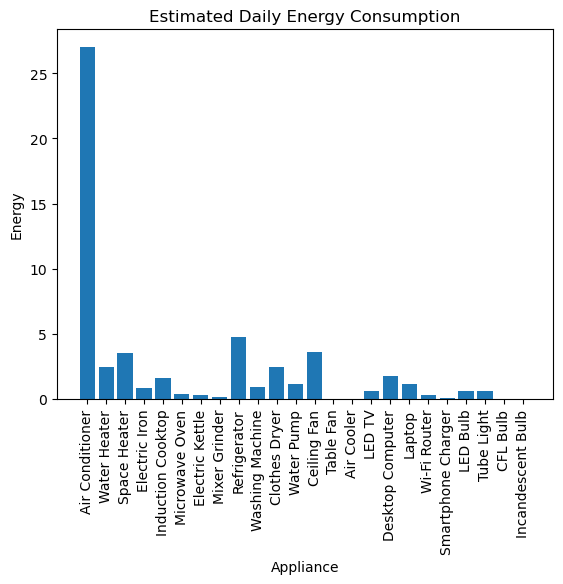

In [31]:
df["daily_kwh"] = (
    df["power_w"] * df["count"] * df["default_hours"]
) / 1000

plt.bar(df["name"], df["daily_kwh"])

plt.title("Estimated Daily Energy Consumption")
plt.xlabel("Appliance")
plt.ylabel("Energy")
plt.xticks(rotation=90)

plt.show()

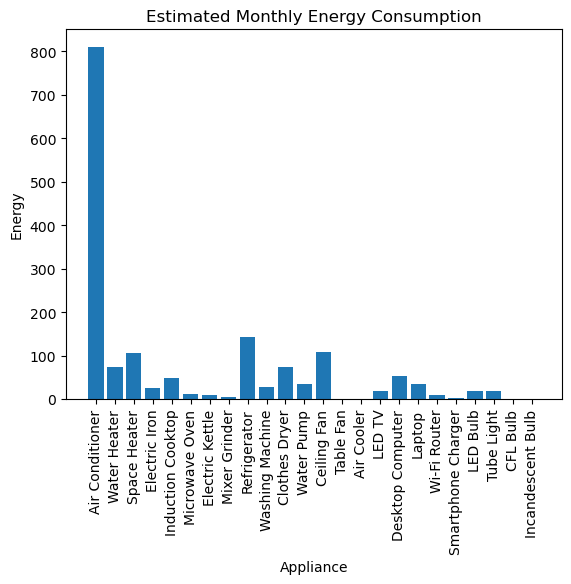

In [33]:
df["monthly_kwh"] = df["daily_kwh"] * 30
plt.bar(df["name"], df["monthly_kwh"])

plt.title("Estimated Monthly Energy Consumption")
plt.xlabel("Appliance")
plt.ylabel("Energy")
plt.xticks(rotation=90)
plt.show()